<a href="https://colab.research.google.com/github/SweetPeaccchhh/API_Tyurmenko-Kravchenko-Dymshakova/blob/main/%D0%9F%D1%80%D0%BE%D0%B3%D1%80%D0%B0%D0%BC%D0%BC%D0%BD%D1%8B%D0%B5_%D0%B8%D0%BD%D1%81%D1%82%D1%80%D1%83%D0%BC%D0%B5%D0%BD%D1%82%D1%8B_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_%D0%A2%D1%8E%D1%80%D0%BC%D0%B5%D0%BD%D0%BA%D0%BE_%D0%94%D0%B0%D1%80%D1%8C%D1%8F%2C_%D0%A0%D0%98_431002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Обнаружение сетевых вторжений на основе датасета UNSW-NB15**

**Бизнес-постановка задачи:** выявить вредоносный трафик.

**Кому задача актуальна?** Компании, которой нужно автоматически выявлять вредоносный трафик и блокировать в режиме реального времени для избежания утечки данных.

**Постановка ML-задачи:** бинарная классификация. На входе - признаки сетевого вторжения, на выходе - метка (0 - норма, 1 - атака). Тренировка модели происходит с помощью файла "UNSW_NB15_training-set.csv", а проверка - "UNSW_NB15_testing-set.csv"

**Набор данных, достаточный для решения поставленной задачи**

Используется датасет UNSW_NB15 для тренировки модели и проверки ее работы.

Около 45 признаков: 11 вещественных (float64: dur, rate, sload...), 30 целочисленных (int64: spkts, sbytes, sttl...) и 4 категориальных (object: proto, service, state, attack_cat)

9 типов атак: Fuzzers, Analysis, Backdoors, DoS, Exploits, Generic, Reconnaissance, Shellcode, Worms   

Колонка attack_cat (тип атаки) в модель подаваться не будет, так как при реальном предсказании тип атаки неизвестен. Будет искользоваться только колонка label (0/1)

**Метрика для измерения качества.**

Для начала необходимо определить, какие типы ошибок будут наиболее высокую цену:
1) False Negative (ложно отрицательная): атака будет пропущена, а значит система будет взломана и данные утекут. Критично.
2) False Positive (ложно положительная): нормальный трафик признан атакой, аналитик потратит время на проверку. Не критично.

Значит **метрика Accuracy точно не подойдет**, так как в реальных сетях нормального трафика больше, чем атак. Если модель всегда будет говорить «атаки нет», она получит Accuracy = 70% (если атак 30%, а нормального состояния - 70%), но не поймает ни одной атаки.

Будет **использоваться метрика Recall (полнота)**, которая показывает, какую долю реальных атак модель смогла поймать.
Recall = пойманные атаки/все атаки. Например, если всего было 100 атак, а поймано 90, то Recall = 90%. Метрика показывает, сколько атак не было замечено.

**Необходимо дополнительно использовать метрику F1-score** - гармоническое среднее между Precision (точность) = правильно названные атаки/все, что модель назвала атакой и Recall.

Если использовать только метрику Recall, модель будет все называть атаками, и метрика будет равна 100%. Будет много ложных срабатываний.

Если использовать только метрику Precision, модель может назвать только 1 атаку, где точно уверена и метрика будет равна 100%, в то время как Recall = 0%. Все атаки в итоге останутся незамеченными.

С помощью метрики F1-score будет найден баланс между Recall и Precision.



**Проведение EDA**

 Базовые характеристики/статистики для набора данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('UNSW_NB15_training-set.csv')
test = pd.read_csv('UNSW_NB15_testing-set.csv')

print("Форма train:", train.shape)
print("Форма test:", test.shape)
print("\nИнформация о данных:")
print(train.info())
print("\nОписательные статистики:")
print(train.describe())
print("\nПропуски:")
print(train.isnull().sum().sum())

Форма train: (82332, 45)
Форма test: (175341, 45)

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15

Обучающая выборка (training-set.csv) содержит 82 332 записи, тестовая (testing-set.csv) — 175 341 запись. Оба набора имеют 45 признаков: 11 вещественных (float64), 30 целочисленных (int64) и 4 категориальных (object: proto, service, state, attack_cat). Пропусков в данных нет.

In [ ]:
print(train.shape, test.shape)

(82332, 45) (175341, 45)


Наиболее релевантные визуализации

График №1: распределение классов (сколько нормы и атак)

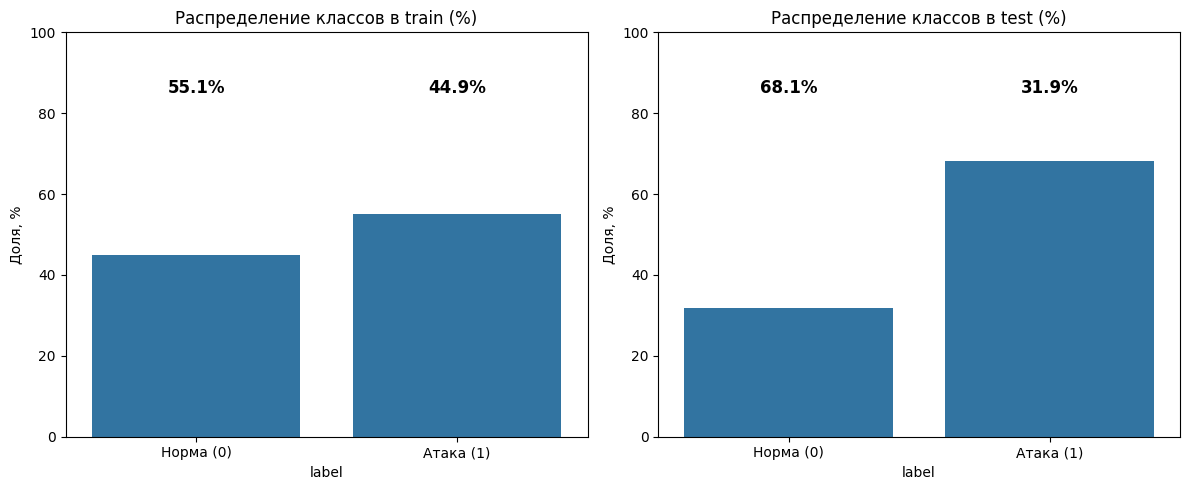

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train
train_pct = train['label'].value_counts(normalize=True) * 100
sns.barplot(x=train_pct.index, y=train_pct.values, ax=axes[0])
axes[0].set_title('Распределение классов в train (%)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Норма (0)', 'Атака (1)'])
axes[0].set_ylabel('Доля, %')
axes[0].set_ylim(0, 100)

# Подписи процентов над столбиками
for i, v in enumerate(train_pct.values):
    axes[0].text(i, 85, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Test
test_pct = test['label'].value_counts(normalize=True) * 100
sns.barplot(x=test_pct.index, y=test_pct.values, ax=axes[1])
axes[1].set_title('Распределение классов в test (%)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Норма (0)', 'Атака (1)'])
axes[1].set_ylabel('Доля, %')
axes[1].set_ylim(0, 100)

for i, v in enumerate(test_pct.values):
    axes[1].text(i, 85, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Описание полученного результата.**

Распределение классов в train и test отличается. В train доли нормы и атак близки (55,1%/44,9%), а в test преобладают атаки (68,1%/31,9%). Это означает, что:

Скорее всего, в датасете UNSW-NB15 train и test специально разделены так, чтобы проверить устойчивость модели к изменению пропорций классов.

Разное распределение train и test означает, что метрики могут отличаться. Поэтому нужно:

1) сравнивать качество модели на обоих наборах;
2) проверять, что модель не «подстраивается» под распределение train.

График: распределение числовых признаков по классам

dur - длительность соединения

sbytes - байты от источника к получателю

dbytes - байты от получателя к источнику

rate - скорость передачи данных

sttl - TTL (время жизни) от источника

dttl - TTL от получателя

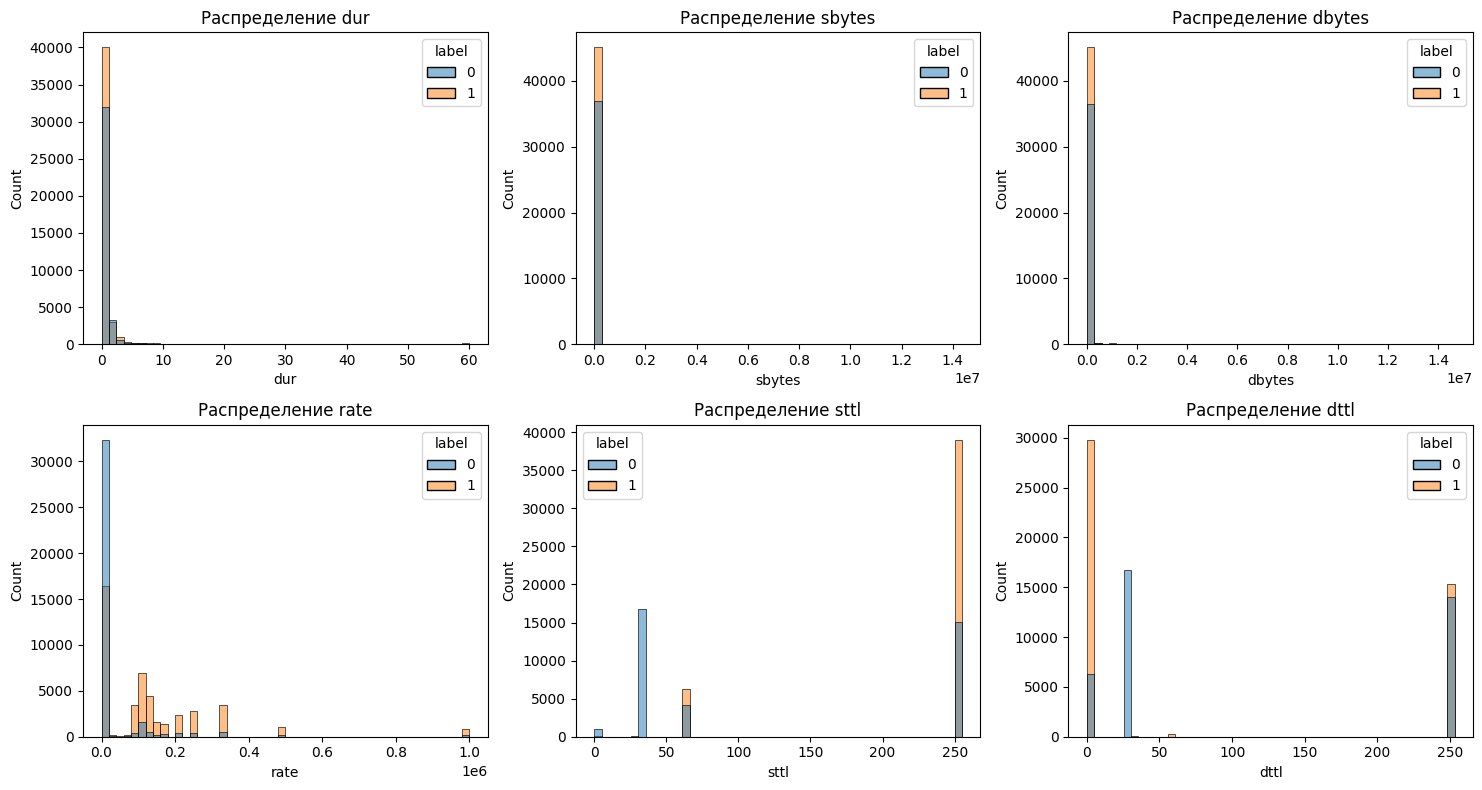

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
numeric_features = ['dur', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl']
for i, col in enumerate(numeric_features):
    ax = axes[i//3, i%3]
    sns.histplot(data=train, x=col, hue='label', bins=50, ax=ax, alpha=0.5)
    ax.set_title(f'Распределение {col}')
plt.tight_layout()
plt.show()

**Описание полученного результата.**

Из гистограмм видно, как распределены значения признаков отдельно для нормы (0) и атак (1):

1) dur - почти все соединения короткие (<5 сек), распределение сжато у нуля. Длинные соединения - единичные случаи. Признак слабо разделяет классы.
2) sbytes, dbytes - большинство соединений имеют очень маленькое количество байт (близко к 0). Редкие выбросы с миллионами байт не видны на графике могут быть из-за масштаба. Поэтому распределение выглядит как один столбик у нуля.
3) rate - у нормы почти всегда около нуля, у атак - большой разброс. Признак полезный: высокая скорость характерна для DoS-атак.
4) sttl, dttl -  нормы три пика, у атак - почти все на 254 (или около 0 у dttl). TTL = 254 нетипичен для нормального трафика. Одни из самых важных признаков для модели.

Что нужно будет сделать:

- Логарифмировать: sbytes, dbytes, rate. Использовать np.log1p (он сжимает большие значения и делает распределение ровнее).
- dur не трогать - распределение нормальное
- Стандартизировать все числовые признаки через StandardScaler
- Проверить корреляции между sbytes/dbytes и sttl/dttl - возможно, дублируют
- sttl и dttl — ключевые признаки

График: матрица корреляций

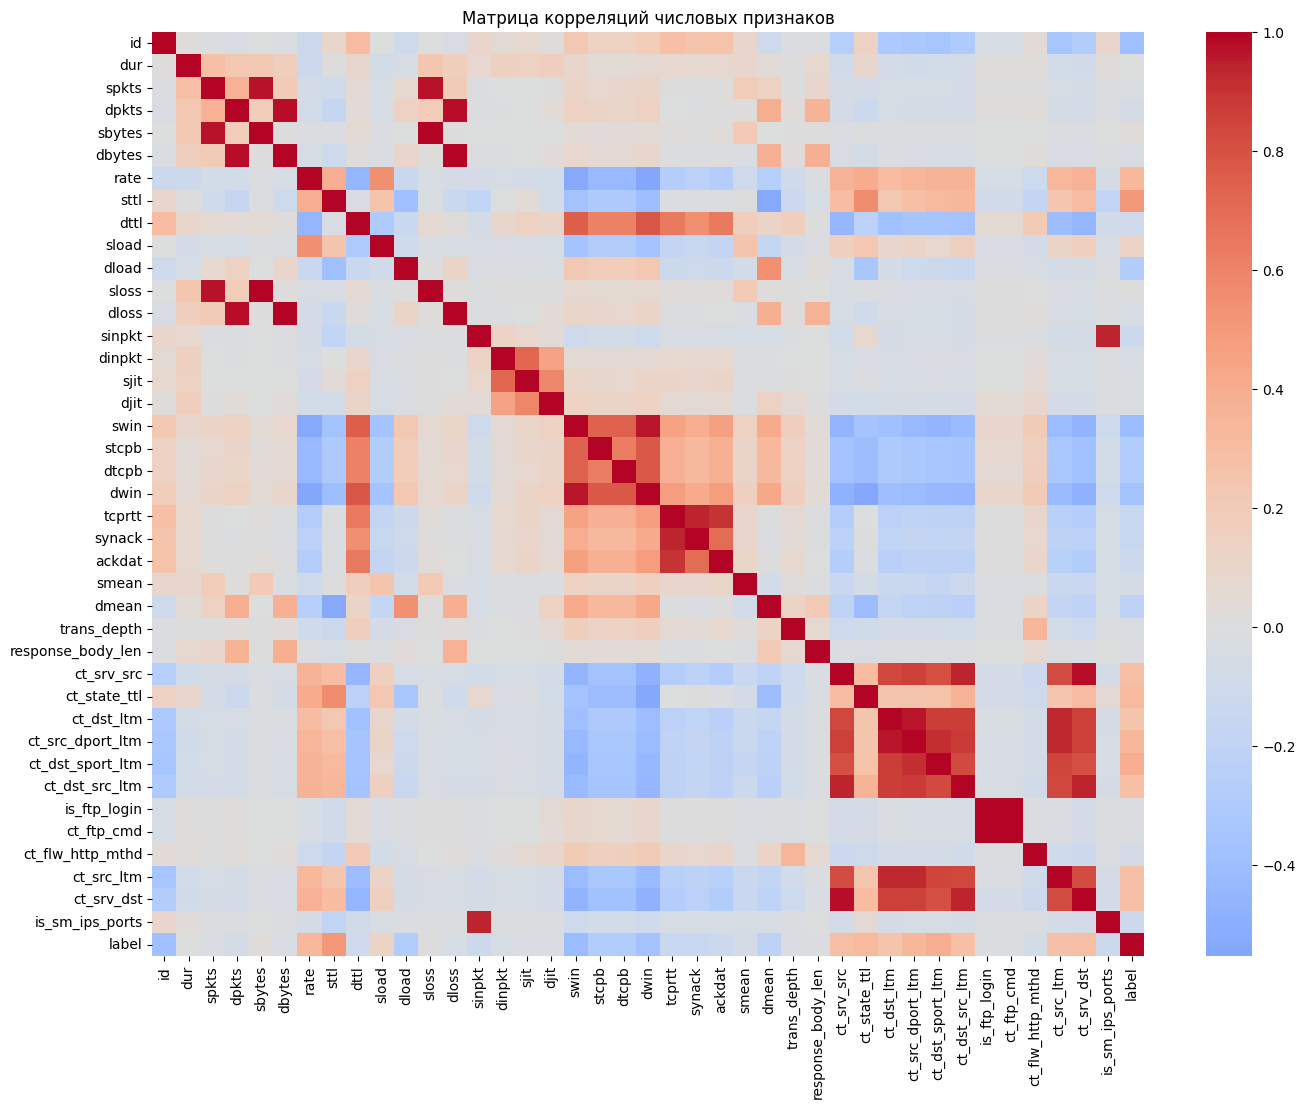

In [ ]:
plt.figure(figsize=(16, 12))
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr = train[numeric_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True)
plt.title('Матрица корреляций числовых признаков')
plt.show()

На графике видно, что некоторые признаки сильно связаны друг с другом и дублируют информацию:

- пакеты и байты (spkts, dpkts, sbytes, dbytes)
- нагрузка и потери (sload, dload, sloss, dloss)
- тайминги TCP (sinpkt, sjit, swin...)
- счетчики соединений (ct_src_ltm, ct_dst_ltm...)

Это не мешает модели, но создает лишнюю нагрузку.

Целевая переменная label почти ни с чем не коррелирует. Значит, ни один признак сам по себе не указывает на атаку, и нужна комбинация.

На будущее: можно удалить по одному признаку из каждой дублирующей пары, но для первой попытки лучше оставить все и посмотреть на важность признаков

График №4: какие типы атак встречаются чаще всего

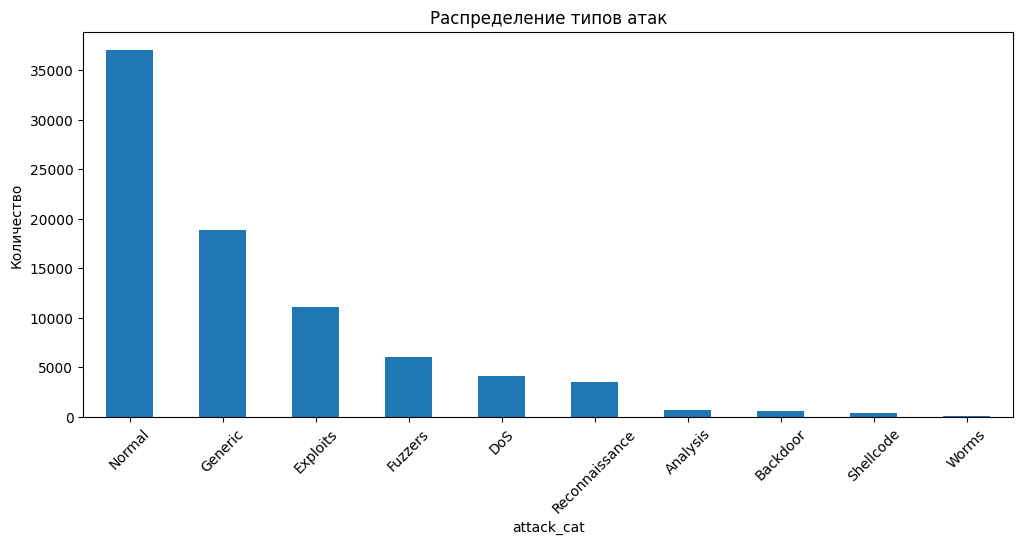

In [ ]:
plt.figure(figsize=(12, 5))
train['attack_cat'].value_counts().plot(kind='bar')
plt.title('Распределение типов атак')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()

Распределение типов атак. В датасете ярко выражен дисбаланс внутри класса атак. Чаще всего встречаются Generic (около 19 000) и Exploits (около 12 000), реже всего - Shellcode и Worms. Такой разброс означает, что если бы нужно было определить конкретный тип атаки, то модель плохо обучилась бы на редких классах.

В данной задаче 9 типов атак объединяются в один класс. Дисбаланс внутри класса атак не влияет на качество. Важно только общее соотношение нормы и атак.